In [1]:
pip install pykan torch torchvision matplotlib scikit-learn tqdm numpy torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 3.2 MB/s eta 0:00:00


In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from kan import KAN
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
from tqdm import tqdm
import torch.nn.functional as F
from torchinfo import summary
import matplotlib.pyplot as plt


# ------------------ Гиперпараметры ------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
epochs = 20
feature_dim = 128

Device: cpu


In [ ]:

# ------------------ CNN Backbone ------------------
class CNNBackbone(nn.Module):
    def __init__(self, out_dim=feature_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.fc = nn.Linear(64 * 4 * 4, out_dim)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


In [ ]:
from torchvision.datasets import STL10

class STL10Fixed(STL10):
    def _check_integrity(self):
        return True

# Загрузка данных STL-10
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(92, padding=2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

train_dataset = STL10Fixed(
    root='/content/drive/MyDrive/KAN_MAFA_Project/STL10_CNN_MLP_KAN/data',
    split='train',
    download=False,
    transform=transform_train
)

test_dataset = STL10Fixed(
    root='/content/drive/MyDrive/KAN_MAFA_Project/STL10_CNN_MLP_KAN/data',
    split='test',
    download=False,
    transform=transform_test
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [5]:
print("=== Этап 1: Обучение CNN + MLP ===")

backbone_mlp = CNNBackbone(out_dim=feature_dim).to(device)
mlp_head = nn.Sequential(
    nn.Linear(feature_dim, 32),
    nn.ReLU(),
    nn.Linear(32, 10)
).to(device)

optimizer_mlp = optim.Adam(list(backbone_mlp.parameters()) + list(mlp_head.parameters()), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Метрики
train_losses_mlp = []
val_losses_mlp = []
val_accs_mlp = []

for epoch in range(epochs):
    backbone_mlp.train()
    mlp_head.train()
    running_loss = 0.0
    correct, total = 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer_mlp.zero_grad()
        feats = backbone_mlp(x)
        logits = mlp_head(feats)
        loss = criterion(logits, y)
        loss.backward()
        optimizer_mlp.step()

        running_loss += loss.item() * x.size(0)
        _, pred = logits.max(1)
        total += y.size(0)
        correct += pred.eq(y).sum().item()

    train_loss = running_loss / total
    train_acc = 100. * correct / total
    train_losses_mlp.append(train_loss)

    # Валидация
    backbone_mlp.eval()
    mlp_head.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            feats = backbone_mlp(x)
            logits = mlp_head(feats)
            loss = criterion(logits, y)
            val_loss += loss.item() * x.size(0)
            _, pred = logits.max(1)
            val_total += y.size(0)
            val_correct += pred.eq(y).sum().item()

    val_loss /= val_total
    val_acc = 100. * val_correct / val_total
    val_losses_mlp.append(val_loss)
    val_accs_mlp.append(val_acc)

    print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")

mlp_acc = val_accs_mlp[-1]
print(f"MLP Accuracy (final): {mlp_acc:.4f}")

# Сохранение моделей

torch.save({
    'model_backbone': backbone_mlp.state_dict(),
    'model_head': mlp_head.state_dict(),
    'optimizer': optimizer_mlp.state_dict(),
    'history': {
        'train_losses': train_losses_mlp,
        'val_losses': val_losses_mlp,
        'val_accs': val_accs_mlp
    }
}, '/content/drive/MyDrive/KAN_MAFA_Project/STL10_CNN_MLP_KAN/full_checkpoint.pth')

print("CNN + MLP сохранены")

=== Этап 1: Обучение CNN + MLP ===
Epoch  1/20 | Train Loss: 1.9957 Acc: 25.96% | Val Loss: 1.6559 Acc: 37.25%
Epoch  2/20 | Train Loss: 1.6060 Acc: 38.88% | Val Loss: 1.5538 Acc: 39.10%
Epoch  3/20 | Train Loss: 1.5179 Acc: 42.08% | Val Loss: 1.4443 Acc: 47.23%
Epoch  4/20 | Train Loss: 1.4101 Acc: 47.16% | Val Loss: 1.3425 Acc: 50.10%
Epoch  5/20 | Train Loss: 1.3615 Acc: 49.82% | Val Loss: 1.3138 Acc: 51.89%
Epoch  6/20 | Train Loss: 1.2913 Acc: 51.10% | Val Loss: 1.2470 Acc: 54.71%
Epoch  7/20 | Train Loss: 1.2550 Acc: 53.64% | Val Loss: 1.2471 Acc: 54.50%
Epoch  8/20 | Train Loss: 1.2179 Acc: 55.08% | Val Loss: 1.2731 Acc: 53.21%
Epoch  9/20 | Train Loss: 1.2000 Acc: 55.76% | Val Loss: 1.2426 Acc: 55.09%
Epoch 10/20 | Train Loss: 1.1487 Acc: 57.90% | Val Loss: 1.1428 Acc: 59.02%
Epoch 11/20 | Train Loss: 1.1060 Acc: 59.22% | Val Loss: 1.1700 Acc: 57.24%
Epoch 12/20 | Train Loss: 1.0905 Acc: 59.82% | Val Loss: 1.1843 Acc: 58.17%
Epoch 13/20 | Train Loss: 1.0565 Acc: 61.38% | Val Lo

In [6]:
# ------------------ Этап 2: CNN + KAN ------------------
print("\n=== Этап 2: Обучение CNN + KAN ===")

# Загрузка backbone
backbone_kan = CNNBackbone(out_dim=feature_dim).to(device)
backbone_kan.load_state_dict(torch.load('/content/drive/MyDrive/KAN_MAFA_Project/STL10_CNN_MLP_KAN/backbone_mlp.pth', map_location=device))
for p in backbone_kan.parameters():
    p.requires_grad = False
backbone_kan.eval()

def extract_features(loader, backbone):
    feats_list, labels_list = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            feats = backbone(x)
            feats_list.append(feats.cpu())
            labels_list.append(y)
    return torch.cat(feats_list, dim=0), torch.cat(labels_list, dim=0)

print("Извлечение признаков...")
X_train_feat, y_train = extract_features(train_loader, backbone_kan)
X_test_feat,  y_test  = extract_features(test_loader,  backbone_kan)

print(f"Признаки train: {X_train_feat.shape}, labels: {y_train.shape}")
print(f"Признаки test:  {X_test_feat.shape},  labels: {y_test.shape}")


y_train_onehot = F.one_hot(y_train, num_classes=10).float()
y_test_onehot = F.one_hot(y_test, num_classes=10).float()

dataset_kan = {
    'train_input': X_train_feat,
    'train_label': y_train_onehot,
    'test_input': X_test_feat,
    'test_label': y_test_onehot
}

# KAN
kan = KAN(width=[feature_dim, 64, 10], grid=5, k=3)
kan = kan.speed()

# Обучение
print("Обучение KAN...")
history = kan.fit(dataset_kan, steps=200, log=10)

# Оценка
kan.eval()
with torch.no_grad():
    pred_kan = kan(X_test_feat)
    pred_labels = pred_kan.argmax(dim=1).cpu().numpy()

kan_acc = accuracy_score(y_test.cpu().numpy(), pred_labels)
print(f"KAN Accuracy: {kan_acc:.4f}")
torch.save({
    'model_backbone': backbone_mlp.state_dict(),
    'model_head': mlp_head.state_dict(),
    'kan_model': kan.state_dict(),
    'history': {
        'train_losses': train_losses_mlp,
        'val_losses': val_losses_mlp,
        'val_accs': val_accs_mlp
    },
    'kan_history': history,
    'mlp_acc': mlp_acc,
    'kan_acc': kan_acc
}, '/content/drive/MyDrive/KAN_MAFA_Project/STL10_CNN_MLP_KAN/full_checkpoint.pth')


print("KAN сохранён в 'kan_model.pth'")



=== Этап 2: Обучение CNN + KAN ===
Извлечение признаков...
Признаки train: torch.Size([5000, 128]), labels: torch.Size([5000])
Признаки test:  torch.Size([8000, 128]),  labels: torch.Size([8000])
checkpoint directory created: ./model
saving model version 0.0
Обучение KAN...
| train_loss: 3.70e-02 | test_loss: 3.97e-01 | reg: 0.00e+00 | : 100%|█| 200/200 [2:18:32<00:00, 41.

KAN Accuracy: 0.6601


In [ ]:
# ------------------ Загрузка чекпоинта ------------------
checkpoint_path = '/content/drive/MyDrive/KAN_MAFA_Project/STL10_CNN_MLP_KAN/full_checkpoint.pth'
checkpoint = torch.load(checkpoint_path, map_location=device)

# Метрики MLP
train_losses_mlp = checkpoint['history']['train_losses']
val_losses_mlp   = checkpoint['history']['val_losses']
val_accs_mlp     = checkpoint['history']['val_accs']
mlp_acc          = val_accs_mlp[-1] / 100.0

# KAN метрики
kan_acc = checkpoint.get('kan_acc')
kan_history = checkpoint.get('kan_history', None)

# Восстановление backbone

backbone = CNNBackbone(out_dim=128).to(device)
backbone.load_state_dict(checkpoint['model_backbone'])
backbone.eval()

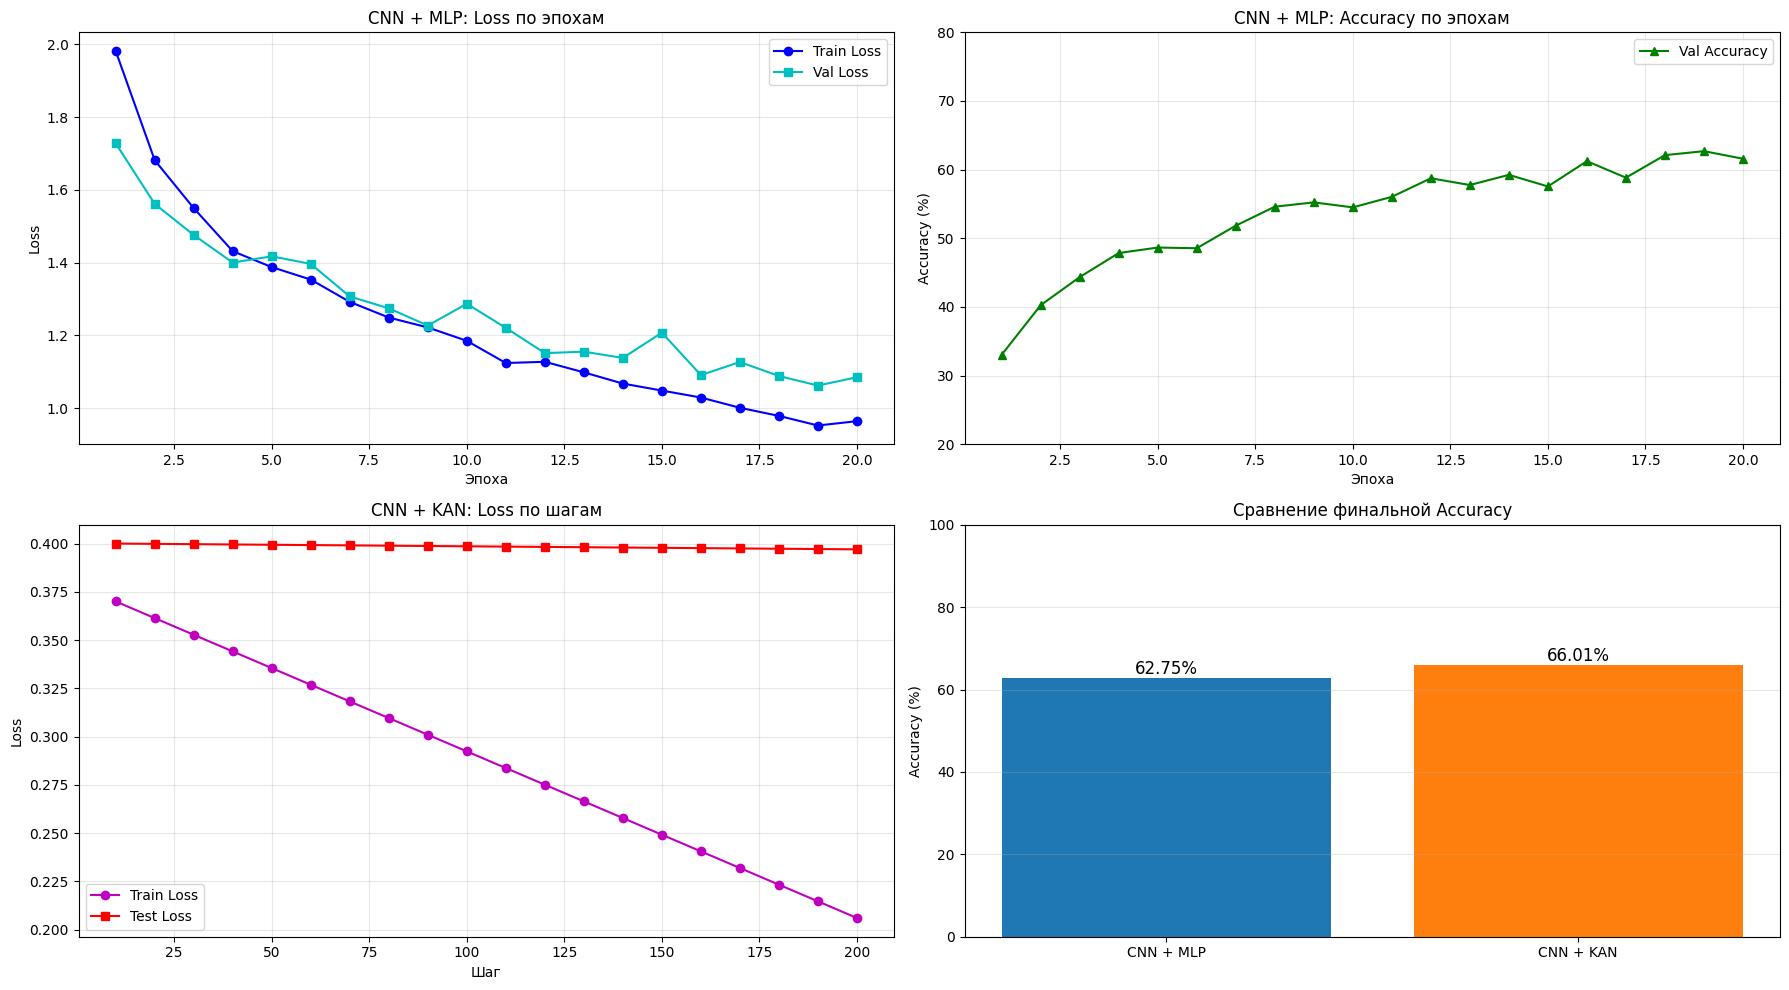

In [7]:
epochs_range = list(range(1, len(train_losses_mlp) + 1))

fig = plt.figure(figsize=(18, 10))

# MLP Loss
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(epochs_range, train_losses_mlp, 'b-o', label='Train Loss')
ax1.plot(epochs_range, val_losses_mlp, 'c-s', label='Val Loss')
ax1.set_title('MLP: Loss')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# MLP Accuracy
ax2 = fig.add_subplot(2, 3, 2)
ax2.plot(epochs_range, val_accs_mlp, 'g-^', label='Val Acc')
ax2.set_title('MLP: Accuracy')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(20, 80)
ax2.legend()
ax2.grid(True, alpha=0.3)

# KAN Loss
if kan_history and 'train_loss' in kan_history:
    steps = list(range(1, len(kan_history['train_loss']) + 1))
    ax3 = fig.add_subplot(2, 3, 3)
    ax3.plot(steps, kan_history['train_loss'], 'm-o', label='Train Loss')
    if 'test_loss' in kan_history:
        ax3.plot(steps, kan_history['test_loss'], 'r-s', label='Test Loss')
    ax3.set_title('KAN: Loss')
    ax3.set_xlabel('Шаг')
    ax3.set_ylabel('Loss')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
else:
    ax3 = fig.add_subplot(2, 3, 3)
    ax3.text(0.5, 0.5, 'Нет истории KAN', ha='center', va='center')
    ax3.set_title('KAN: Loss')
    ax3.axis('off')

# Сравнение Accuracy
ax4 = fig.add_subplot(2, 3, 4)
models = ['MLP', 'KAN']
accs = [mlp_acc*100, kan_acc*100]
bars = ax4.bar(models, accs, color=['blue', 'orange'])
ax4.set_title('Accuracy сравнение')
ax4.set_ylabel('Accuracy (%)')
ax4.set_ylim(0, 100)
for bar in bars:
    h = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.2f}%', ha='center')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()